# 2012: Cramers V feature selection & LR/LGBM- models

## Import / Install libraries

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV

%pip install lightgbm
%pip install shap
import lightgbm as lgb
import shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Feature Selection - Cramér’s V 

In [56]:
df = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet')

# after first run, features were identified that did not add to the accuracy or had high collinearity. These are now dropped: 
remove_var = ["cand_baseline", "izip_baseline", "lookupzip_baseline", "pid7_baseline", "ideo5_baseline", "cmatch_ging_baseline",     
    "fav_obama_baseline",
    "pid7_baseline",
    "ideoobama_baseline",
    "univhealthcov_baseline",
    "prim12_baseline",
    "likeobama_baseline",
    "ideo5_baseline", "presvote08_baseline", "cong2012_2_baseline", "post_pid7_2012",
    "selfdescr_ccap_7_baseline", "straighttic_baseline", "pid3_baseline"]
df = df.drop(columns = remove_var)
df.to_csv("data/df_2012_droppedvariables.csv")

In [57]:
#spot perfect (and weak) association

# Cramers V: Effect size measure for association between two nominal variables (0 = no association, 1 = perfect association).
# Based on chi-square statistic.

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

#df = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet')   
target = df['presvote16post_2016']                        #use different target variable
features = df.drop(columns=['presvote16post_2016'])

scores = {}
for col in features.columns:
    try:
        scores[col] = cramers_v(features[col].astype(str), target.astype(str))
    except:
        scores[col] = 0

ranked = pd.Series(scores).sort_values(ascending=False)
print(ranked.head(25))  

# https://www.scribbr.de/statistik/cramers-v/ --> Here we have an interpretation (but not that important for us)
# 0-0.2: schwacher Zusammenhang
# 0.2-0.6: mittlerer Zusammenhang
# 0.6-1: starker Zusammenhang



/tmp/ipykernel_2833/711362706.py:11: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2 / (n * (min(r, k) - 1)))


post_presvote12_2012         0.883336
cmatch_romn_baseline         0.854363
vote_generic_baseline        0.850106
obamaapp_baseline            0.842266
healthreformbill_baseline    0.815007
teapartsup_baseline          0.814194
post_house12_2012            0.769986
fav_biden_baseline           0.768580
healthqualch3_baseline       0.745544
post_ideo5_2012              0.721171
govt_reg_baseline            0.719384
fav_hrc_baseline             0.711209
post_pid3_2012               0.699823
healthtaxch3_baseline        0.684840
fav_bach_baseline            0.671457
fav_sant_baseline            0.667141
envwarm_baseline             0.665892
fav_ging_baseline            0.664752
fav_perr_baseline            0.654909
taxwealth_baseline           0.648521
saysobama_baseline           0.642262
envser2_baseline             0.623318
likenewt_baseline            0.604640
track_baseline               0.593166
econtrend_baseline           0.591452
dtype: float64


## Define The (CramersV) Feature Set

In [58]:
top25_cols = ranked.head(25).index.tolist()

df_top25 = df[top25_cols + ["presvote16post_2016"]].dropna() #drop columns that still contain NA's

df_top25.to_csv("data/df_top25_cramersv_2012.csv", index=False) #safe cramersV - feature-selected-data

print(df_top25["presvote16post_2016"].value_counts()) #check proportion again

presvote16post_2016
Hillary Clinton    2634
Donald Trump       1951
Name: count, dtype: int64


## Import Other Feature Sets - Only run when permutation/gini csv

In [48]:
# ONLY RUN IF YOU WANT OTHER FEATURE SELECTION METHOD THAN CRAMERS V

#Cell for importing other feature sets
# hastag this cell if you want cramersV feature set
"""
# load the feature names 
selected_features = pd.read_csv('data/selectedfeautures_gini_2012.csv') # ONLY CHANGE CSV HERE
top25_cols = selected_features['base_name'].tolist()  # extract column names as list

#adds _2016 to any column name that doesn't already have it, and leaves the rest unchanged
top25_cols = [col + '_2016' if not col.endswith('_2016') else col for col in selected_features['base_name'].tolist()]

# load the original data and select those features — same logic as Cramér's V cell
df = pd.read_parquet('data/votersurvey_cleaned_noDropNA_2012.parquet')
df_top25 = df[top25_cols + ['presvote16post_2016']].dropna()

print(df_top25.columns)
print(df_top25["presvote16post_2016"].value_counts())  # check proportion
"""

'\n# load the feature names \nselected_features = pd.read_csv(\'data/selectedfeautures_gini_2012.csv\') # ONLY CHANGE CSV HERE\ntop25_cols = selected_features[\'base_name\'].tolist()  # extract column names as list\n\n#adds _2016 to any column name that doesn\'t already have it, and leaves the rest unchanged\ntop25_cols = [col + \'_2016\' if not col.endswith(\'_2016\') else col for col in selected_features[\'base_name\'].tolist()]\n\n# load the original data and select those features — same logic as Cramér\'s V cell\ndf = pd.read_parquet(\'data/votersurvey_cleaned_noDropNA_2012.parquet\')\ndf_top25 = df[top25_cols + [\'presvote16post_2016\']].dropna()\n\nprint(df_top25.columns)\nprint(df_top25["presvote16post_2016"].value_counts())  # check proportion\n'

## Collinearity Check - Cramers V Heatmap

In [43]:
# removing variables
#cutoff: collinearity > 65 
#already dropping them at the top
#rv = ["cand_baseline", "izip_baseline", "lookupzip_baseline", "pid7_baseline", "ideo5_baseline", "cmatch_ging_baseline"]
#top25_cols = [col for col in top25_cols if col not in rv]

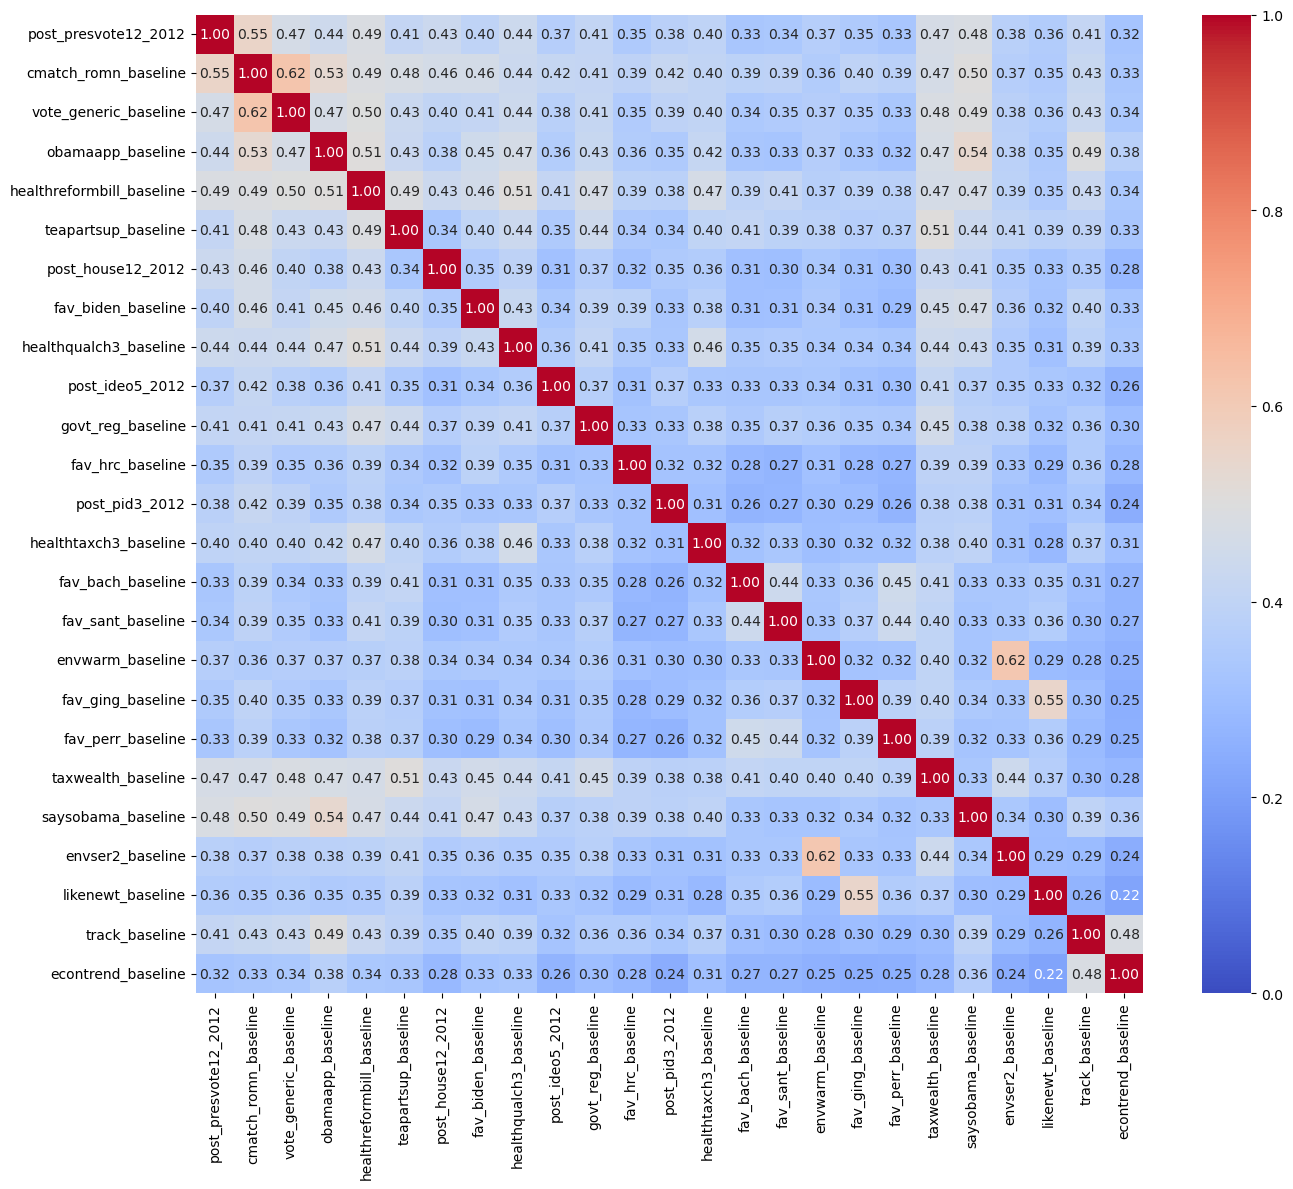

In [59]:
# Here I try to check for collinerity

#Cramers V - heatmap

cramers_matrix = pd.DataFrame(index=top25_cols, columns=top25_cols, dtype=float)
for col1 in top25_cols:
    for col2 in top25_cols:
        try:
            cramers_matrix.loc[col1, col2] = cramers_v(df_top25[col1].astype(str), df_top25[col2].astype(str))
        except:
            cramers_matrix.loc[col1, col2] = 0

plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.tight_layout()
plt.savefig('results/LR_LGBM/CV_collinearityheatmap_2012.png', bbox_inches='tight')
plt.show()



## Cramér's V Score Distribution — Checking for Natural Cutoff

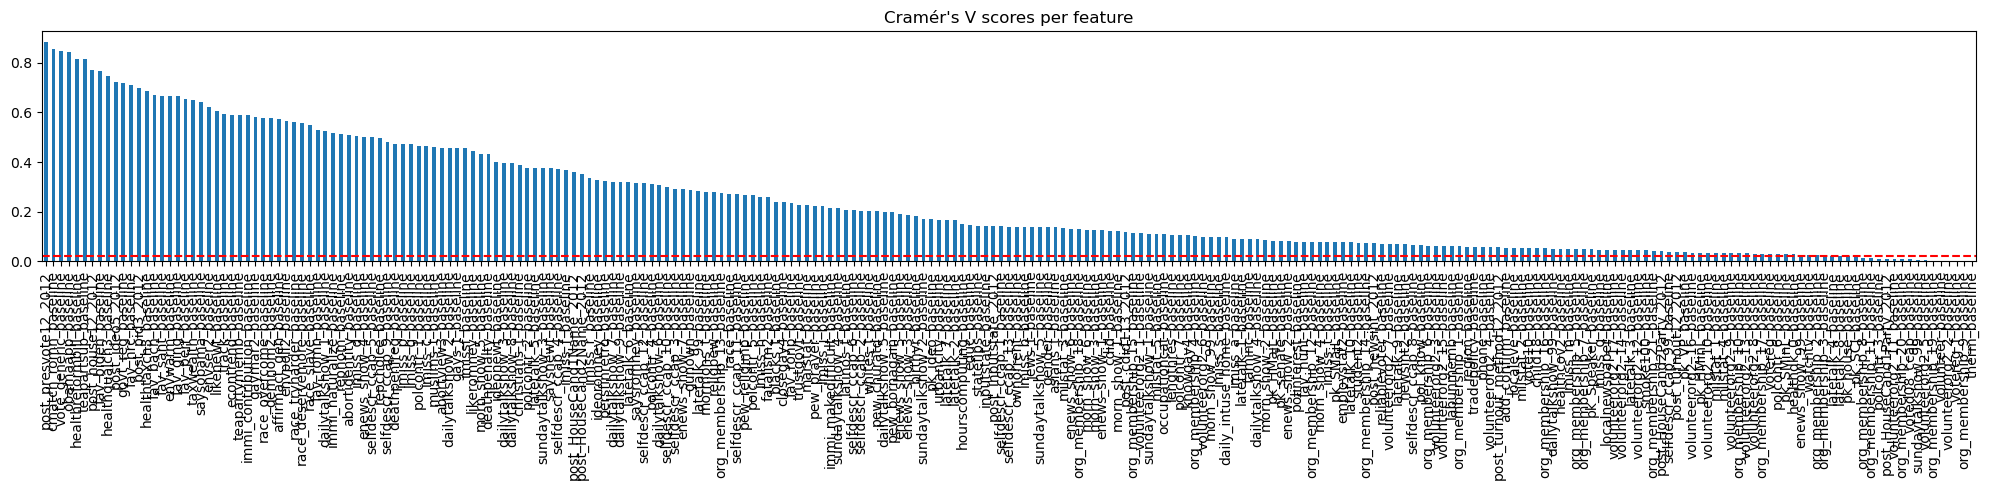

In [60]:
# ellbow method: to see if the Cramers V

ranked.plot(kind='bar', figsize=(20, 5))
plt.axhline(y=0.02, color='red', linestyle='--')
plt.title('Cramér\'s V scores per feature')
plt.tight_layout()
plt.show()

# did not work, gradual increase of feature importance, but first two features seem to have a little jump in the CramersV values


## Data Preparation: Encoding & Train/Test Split // ALLWAYS RUN!

In [61]:
# ── Fix dtypes (object → category) ──────
for col in df_top25.select_dtypes(include='object').columns:
    df_top25[col] = df_top25[col].astype('category')

# ── Define target, features and feature ranking ────────────
y = (df_top25['presvote16post_2016'] == 'Donald Trump').astype(int)  # Trump=1, Clinton=0
X = df_top25.drop(columns=['presvote16post_2016']) # all columns ecept target feature

# column order of df_top25 already reflects ranking order
feature_ranking = X.columns.tolist()

# ── Encode categoricals and split (done once, reused in loop) ──────
cat_cols = X.select_dtypes(include='category').columns.tolist() # find all the categroy columns

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # scikit-learn OrdinalEncoder // unknown ones = -1
X_enc = X.copy()

# fit_transform learns the mapping from X and applies it in one step
X_enc[cat_cols] = enc.fit_transform(X[cat_cols]) # category --> integer

# ── Train/test split ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y) # 80/20 split // (stratify=y ensures both splits have the same Trump/Clinton ratio)

## Hyperparameter Tuning

In [62]:
# ── LightGBM hyperparameter tuning ────────────────────────────────────
lgbm_param_grid = {
    'n_estimators':  [100, 300, 500],        # number of trees
    'learning_rate': [0.01, 0.05, 0.1],      # step size per tree
    'max_depth':     [2, 3, 4],              # tree depth
}
lgbm_search = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    lgbm_param_grid,
    cv=5,                                    # 5-fold cross validation
    scoring='roc_auc',                       # optimize for AUC
    n_jobs=1                                # use all CPU cores
)
lgbm_search.fit(X_train, y_train) #fit; try out all combiantions of parameters
print("Best LGBM params:", lgbm_search.best_params_)
print("Best LGBM AUC:  ", round(lgbm_search.best_score_, 4))

# ── Logistic Regression hyperparameter tuning ─────────────────────────
scaler = StandardScaler() #define scaler

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5],  # regularization strength; smaller = stronger regularization; basically gets penalized for trusting train data to much 
}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid, #different 
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)
lr_search.fit(scaler.fit_transform(X_train), y_train) #fit; try out different "C" parameters
print("Best LR params:", lr_search.best_params_)
print("Best LR AUC:   ", round(lr_search.best_score_, 4))

Best LGBM params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300}
Best LGBM AUC:   0.9796
Best LR params: {'C': 0.01}
Best LR AUC:    0.9754


## Model Fit - Loop With Increasing Features

In [67]:
# post Hyperparameter tuning: 
#-------------
#CramersV:
# lgbm: learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300
# LR:   C = 0.01
# C = how sceptical model is towards training data (train-trust-factor) --> adds a penalty to the loss function

#-------------
#Permutation
#Gini
# --> Slightly different hyperparameters, but I keep the ones from CramersV to be more consistent
#-------------


# ── FIT booth models - Loop through all selected features ───────────────

results = [] #list for results

for n in range(1, len(feature_ranking) + 1):
    top_n = feature_ranking[:n] #select first n features

    X_train_n = X_train[top_n] # define training subset
    X_test_n  = X_test[top_n] # define testing subset

    # Logistic Regression (requires scaling)
    scaler = StandardScaler() #define scaler
    lr = LogisticRegression(max_iter=1000, random_state=42, C=0.01) # max_iter=1000 is enough for the solver to find the solution
    lr.fit(scaler.fit_transform(X_train_n), y_train) #scalling and fitting
    auc_lr = roc_auc_score(y_test, lr.predict_proba(scaler.transform(X_test_n))[:, 1]) # test AUC

    # LightGBM (no scaling needed)
    lgbm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                               max_depth=2, random_state=42, verbose=-1) #verbose=-1 --> only show the clean print
    lgbm.fit(X_train_n, y_train, # fit the LigthGBM model
             eval_set=[(X_test_n, y_test)], # # eval_set: for monitoring test performance
             callbacks=[lgb.early_stopping(50, verbose=False)]) #stop if not getting better for 50 rounds
    auc_lgbm = roc_auc_score(y_test, lgbm.predict_proba(X_test_n)[:, 1]) # test AUC
    # store the info of each iteration
    results.append({
        'n_features':      n, #how many features used
        'added_feature':   top_n[n - 1], # which feature was added
        'auc_lr_train':    round(roc_auc_score(y_train, lr.predict_proba(scaler.transform(X_train_n))[:, 1]), 4), #train AUC for LR
        'auc_lr_test':     round(auc_lr,   4), #test AUC for LR
        'auc_lgbm_train':  round(roc_auc_score(y_train, lgbm.predict_proba(X_train_n)[:, 1]), 4), #train AUC for lgbm
        'auc_lgbm_test':   round(auc_lgbm, 4) #test AUC for lgbm
    })
    print(f"n={n:2d} | LR: {auc_lr:.4f} | LGBM: {auc_lgbm:.4f} | added: {top_n[n-1]}") #formating code

results_df = pd.DataFrame(results) # one row per feature set
results_df.to_csv("data/featureselection_cramersV_LGBMscore_2012.csv") 

n= 1 | LR: 0.9114 | LGBM: 0.9222 | added: post_presvote12_2012
n= 2 | LR: 0.9271 | LGBM: 0.9448 | added: cmatch_romn_baseline
n= 3 | LR: 0.9225 | LGBM: 0.9593 | added: vote_generic_baseline
n= 4 | LR: 0.9272 | LGBM: 0.9608 | added: obamaapp_baseline
n= 5 | LR: 0.9499 | LGBM: 0.9663 | added: healthreformbill_baseline
n= 6 | LR: 0.9520 | LGBM: 0.9701 | added: teapartsup_baseline
n= 7 | LR: 0.9520 | LGBM: 0.9693 | added: post_house12_2012
n= 8 | LR: 0.9558 | LGBM: 0.9705 | added: fav_biden_baseline
n= 9 | LR: 0.9551 | LGBM: 0.9701 | added: healthqualch3_baseline
n=10 | LR: 0.9563 | LGBM: 0.9728 | added: post_ideo5_2012
n=11 | LR: 0.9573 | LGBM: 0.9746 | added: govt_reg_baseline
n=12 | LR: 0.9571 | LGBM: 0.9743 | added: fav_hrc_baseline
n=13 | LR: 0.9637 | LGBM: 0.9748 | added: post_pid3_2012
n=14 | LR: 0.9638 | LGBM: 0.9745 | added: healthtaxch3_baseline
n=15 | LR: 0.9650 | LGBM: 0.9723 | added: fav_bach_baseline
n=16 | LR: 0.9648 | LGBM: 0.9737 | added: fav_sant_baseline
n=17 | LR: 0.968

## LR & LightGBM - Plots

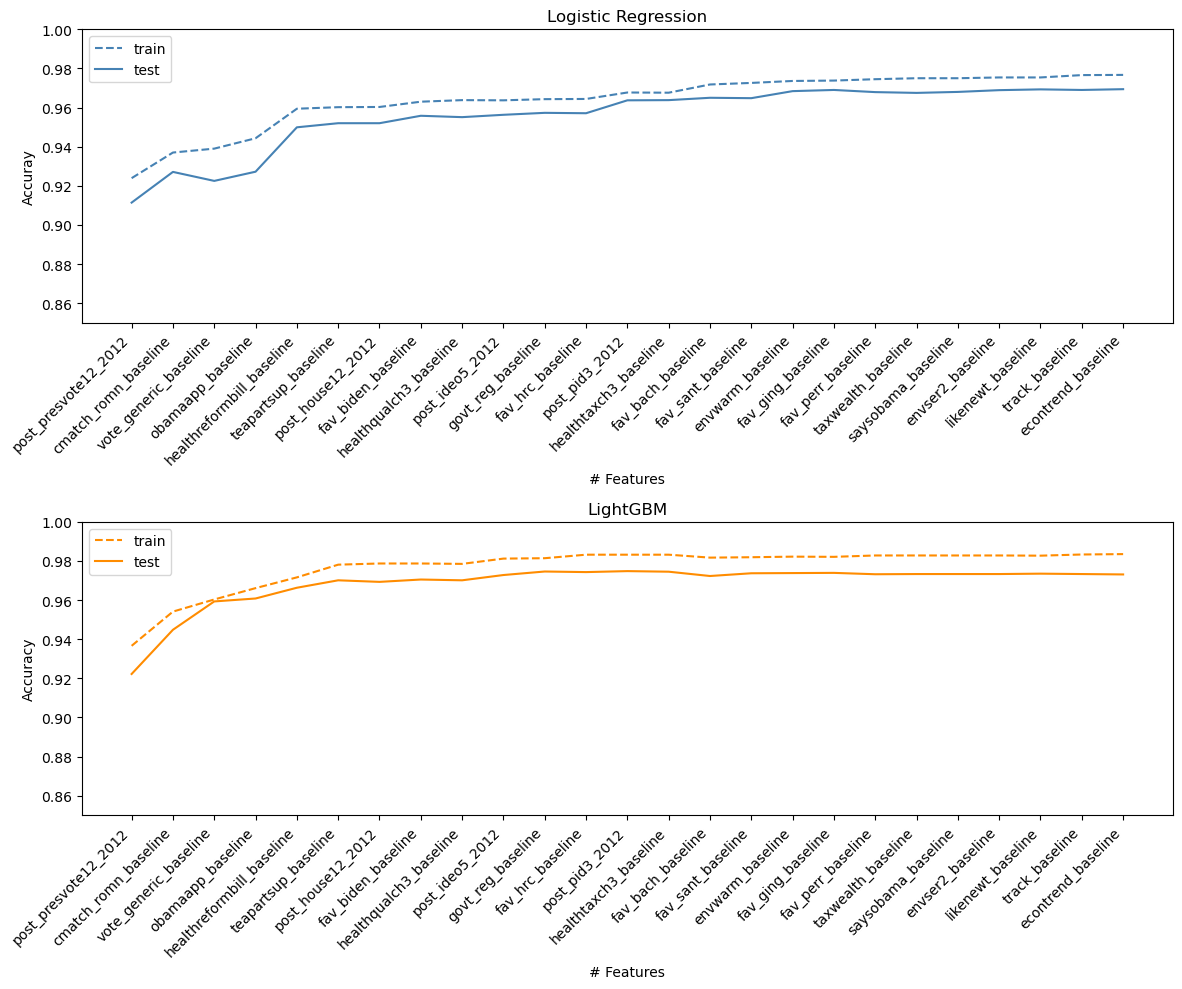

In [64]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

feature_names = results_df['added_feature']
x = range(len(feature_names))

ax1.plot(x, results_df['auc_lr_train'], color='steelblue', linestyle='--', label='train')
ax1.plot(x, results_df['auc_lr_test'],  color='steelblue', linestyle='-',  label='test')
ax1.set_title('Logistic Regression')
ax1.set_xlabel('# Features')
ax1.set_ylabel('Accuray')
ax1.set_ylim(0.85, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(feature_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(False)

ax2.plot(x, results_df['auc_lgbm_train'], color='darkorange', linestyle='--', label='train')
ax2.plot(x, results_df['auc_lgbm_test'],  color='darkorange', linestyle='-',  label='test')
ax2.set_title('LightGBM')
ax2.set_xlabel('# Features')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.85, 1.0)
ax2.set_xticks(x)
ax2.set_xticklabels(feature_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.savefig('results/LR_LGBM/gini_LR_LightGBM_2012.png', bbox_inches='tight')
plt.show()

## Shap Values, Trigger-Questions: Trump vs. Clinton

/opt/conda/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


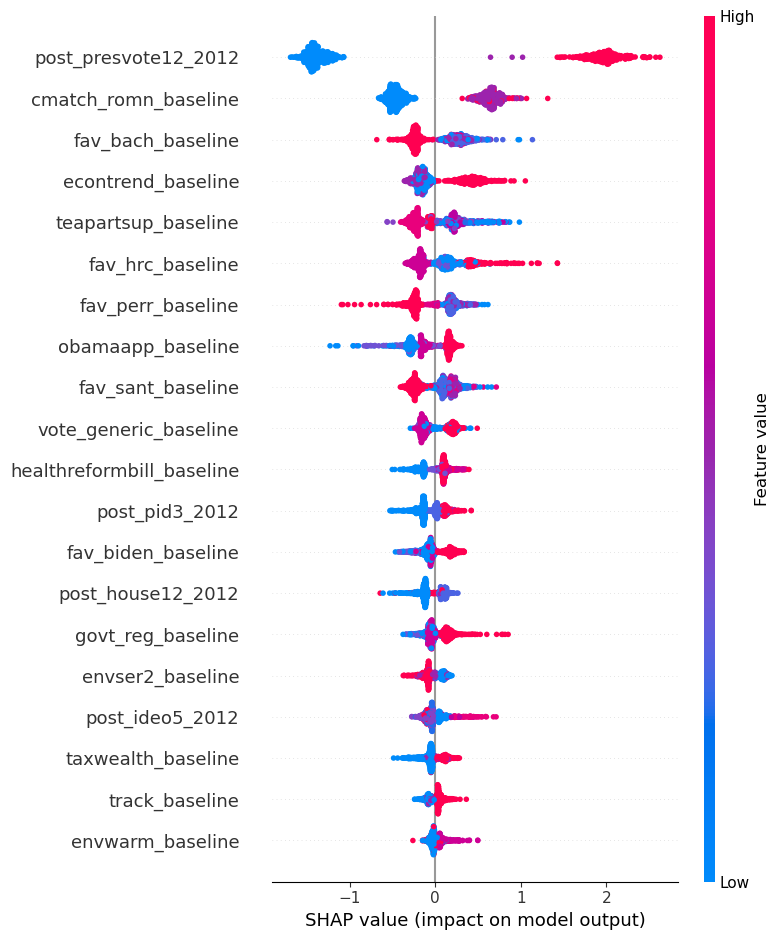


Feature:          post_presvote12_2012
SHAP → Trump:     1.9691   
SHAP → Clinton:   -1.3857  
→ Trump:          Mitt Romney
→ Clinton:        —
------------------------------------------------------------

Feature:          cmatch_romn_baseline
SHAP → Trump:     0.6481   
SHAP → Clinton:   -0.461  
→ Trump:          Mitt Romney
→ Clinton:        —
------------------------------------------------------------

Feature:          vote_generic_baseline
SHAP → Trump:     0.1895   
SHAP → Clinton:   -0.1314  
→ Trump:          The Republican Party candidate
→ Clinton:        The Democratic Party candidate
------------------------------------------------------------

Feature:          obamaapp_baseline
SHAP → Trump:     0.1665   
SHAP → Clinton:   -0.2568  
→ Trump:          Strongly Disapprove
→ Clinton:        Somewhat Approve
------------------------------------------------------------

Feature:          healthreformbill_baseline
SHAP → Trump:     0.114   
SHAP → Clinton:   -0.1706  
→ Tr

In [65]:
# Explanation regarding SHAP values
# https://doi.org/10.48550/arXiv.1705.07874 --> S. 8 // chapter 5.1

# In a nutshell: explains how the model makes decisions // which & how much of a specific feature was used in

# SHAP tells us how strongly a feature influenced the prediction (mean shap) and 
# in which direction ((+) Trump / (-)Clinton)
# the higher the shap value is, the more that feature consistently moved predictions, regardless of direction

# ── 1. Refit LightGBM on all 25 features for SHAP ──────────────────── #same logic as before

lgbm_final = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                 max_depth=6, random_state=42, verbose=-1) #same configuration as before
lgbm_final.fit(X_train, y_train,
               eval_set=[(X_test, y_test)],
               callbacks=[lgb.early_stopping(50, verbose=False)])

# ── 2. Compute SHAP values on test set ───────────────────────────────

# Create an "interpreter"; catches decisions of lgbm
# which specific answers were the "decisive factors" for each prediction.
explainer = shap.TreeExplainer(lgbm_final) 

# execution of the interpreter: finds the tipping points
shap_vals  = explainer.shap_values(X_test)  # positive = pushes toward Trump

# ── 3. Beeswarm plot (uses encoded X_test but shows feature names) ────

shap.summary_plot(shap_vals, X_test, plot_type="dot", show=False) # 1dot per person per feature // color off because numbers are jsut encoded...
#plt.savefig("results/LR_LGBM/shap_plots/gini_shap_plots.png", bbox_inches='tight')
plt.show()

# ── 4. Interpretable summary: feature + raw answer label ──────────────
summary_rows = []

for feat in feature_ranking: # goes through all features in the CramersV-ranking order

    # get the SHAP values for this one feature (one value per person)
    feat_idx = X_test.columns.tolist().index(feat)  # column index of this feature
    shap_col = shap_vals[:, feat_idx]               # calculate SHAP values; in a Matrix

    # focus only on rows where this feature had a strong impact
    strong_impact = np.abs(shap_col) >= np.percentile(np.abs(shap_col), 80)  # True/False mask, top 20% rows(people)

    # get the original (pre-encoding) survey answers for those rows
    strong_answers = X.loc[X_test.index[strong_impact], feat]  # e.g. ["Strongly Disapprove", "Approve", ...]
    strong_shap    = shap_col[strong_impact]                    # their corresponding SHAP values

    # split by direction: positive SHAP = toward Trump, negative = toward Clinton
    trump_answers   = strong_answers[strong_shap > 0]  # e.g. ["Strongly Disapprove", ...]
    clinton_answers = strong_answers[strong_shap < 0]  # e.g. ["Strongly Approve", ...]

    summary_rows.append({
        'feature':          feat, # the feature 
        'shap_→_Trump':     round(shap_col[shap_col > 0].mean(), 4) if (shap_col > 0).sum() > 0 else '—',  # avg push toward Trump (positive-mean)
        'shap_→_Clinton':   round(shap_col[shap_col < 0].mean(), 4) if (shap_col < 0).sum() > 0 else '—',  # avg push toward Clinton (negative-mean)
        'answer_→_Trump':   trump_answers.mode()[0]   if len(trump_answers)   > 0 else '—',  # most common answer among Trump-pushed rows
        'answer_→_Clinton': clinton_answers.mode()[0] if len(clinton_answers) > 0 else '—',  # most common answer among Clinton-pushed rows
    })

summary_df = pd.DataFrame(summary_rows)


for _, row in summary_df.iterrows(): # print all the features, shap value, triggerquestion-trump, trigger-question-clinton
    print(f"""
Feature:          {row['feature']}
SHAP → Trump:     {row['shap_→_Trump']}   
SHAP → Clinton:   {row['shap_→_Clinton']}  
→ Trump:          {row['answer_→_Trump']}
→ Clinton:        {row['answer_→_Clinton']}
{'-'*60}""")

## Notes

 ### ── LightGBM vs Random Forest ───────
 
 #### both are tree-based ensemble methods but differ in strategy:

 Random Forest (Bagging):
   - builds trees independently and in parallel
   - each tree sees a random subset of data
   - final prediction = majority vote of all trees

 LightGBM (Gradient Boosting with focus on speed and efficincy): ... maybe XGBoost would have been more interesting...but yeah I used lGBM and it worked just fine
   - builds trees sequentially
   - each new tree corrects the errors of the previous one
   - final prediction = sum of all trees' contributions

     --> actively learn from mistakes


source: https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf
    
*LightGBM is a combination of: Gradient-based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB)*
- GOSS: keeps only the data points with large gradients (= high errors) for training — speeds up without losing accuracy
- EFB: bundles mutually exclusive features into one — reduces the number of features without losing information

In [66]:
summary_df.to_csv("data/featureselection_cramersV_shapscore_2012.csv") 